# Lab 4 — Assignment


**Based on:** Lab-4-b (Bernoulli, Binomial, Poisson, Normal, Uniform)


---

### Instructions

1. Run the **Setup** cell first. Do not modify it.
2. There are **10 questions** — two on each distribution. Attempt **all** of them.
3. Every question has three parts:
   - **(a)** and **(b)** — work these out **by hand** and type your working in the *Written answer* cell.
   - **(c)** — write **Python code** in the blank code cell provided and produce the plot asked for.
4. Use `DISCRETE_COLOR` for discrete plots (bars) and `CONTINUOUS_COLOR` for continuous plots (curves).
5. Every plot must have an **x-label, y-label and a title**. Marks are deducted for unlabelled plots.
6. Round all probabilities to **4 decimal places**.
7. Save the notebook with all outputs visible before submitting.

### Marks distribution

| Section | Questions | Marks each | Total |
|---|---|---|---|
| A — Bernoulli | Q1, Q2 | 5 | 10 |
| B — Binomial | Q3, Q4 | 5 | 10 |
| C — Poisson | Q5, Q6 | 5 | 10 |
| D — Normal | Q7, Q8 | 5 | 10 |
| E — Uniform | Q9, Q10 | 5 | 10 |
| | | **Total** | **50** |

### Quick reference — which function do I need?

| Task | `scipy.stats` call |
|---|---|
| $P(X = k)$, discrete | `.pmf(k, ...)` |
| $f(x)$, continuous | `.pdf(x, ...)` |
| $P(X \le x)$ | `.cdf(x, ...)` |
| $P(X > x)$ | `.sf(x, ...)` |
| Value with given $P(X \le x)$ | `.ppf(prob, ...)` |
| Mean / variance | `.mean(...)`, `.var(...)` |
| Random samples | `.rvs(..., size=n, random_state=seed)` |

---

## Setup
Run this cell first — do not change it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import comb, factorial, exp, sqrt

DISCRETE_COLOR = "#0E9F9A"     # teal   -> discrete distributions
CONTINUOUS_COLOR = "#E4572E"   # orange -> continuous distributions
HIGHLIGHT_COLOR = "#F4A261"    # use this to highlight a bar or a shaded area

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Setup complete — you are ready to start.")

Setup complete — you are ready to start.


---
# Part A — Bernoulli distribution
*Recall:* $P(X=x) = p^x(1-p)^{1-x}$ for $x \in \{0,1\}$, $\;E[X]=p$, $\;Var(X)=p(1-p)$.

## Q1. The library gate scanner 

> 📚 The RFID gate at the college library reads a student's ID card correctly on the **first tap 92%** of the time. One student taps her card once.
>
> Let $X = 1$ if the card is read on the first tap, and $X = 0$ if it is not.
>
> **(a)** State the value of $p$ and find $P(X=1)$ and $P(X=0)$.
> **(b)** Find the mean and the variance of $X$, showing the substitution into the formulas.
> **(c)** Write Python code that:
> - builds the PMF of $X$ using `stats.bernoulli.pmf`,
> - draws a **bar chart** of the distribution in `DISCRETE_COLOR` with the ticks labelled `"Not read (0)"` and `"Read (1)"`,
> - writes the probability value on top of each bar,
> - prints the mean and the variance obtained from `scipy`, and checks that they match your hand answers in (b).

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 



**(a)** The probability of a correct first tap is $p=0.92$.

$P(X=1)=p=0.92$

$P(X=0)=1-p=1-0.92=0.08$.

**(b)**

$E[X]=p=0.92$

$Var(X)=p(1-p)=0.92(0.08)=0.0736$.


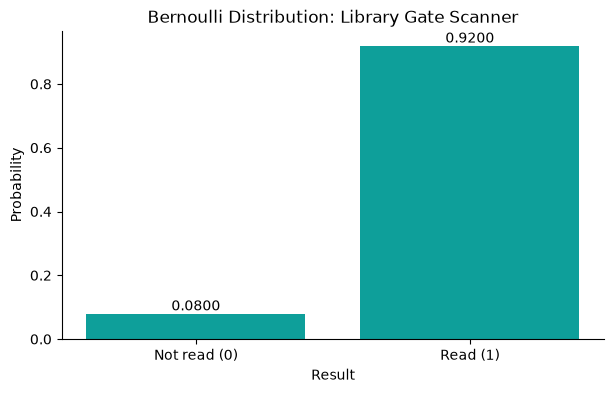

Mean: 0.92
Variance: 0.0736
Mean matches hand answer: True
Variance matches hand answer: True


In [7]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
x=[0,1]
p=.92
pmf=stats.bernoulli.pmf(x,p)
plt.bar(x,pmf,color=DISCRETE_COLOR)
plt.xticks(x,["Not read (0)","Read (1)"])
plt.xlabel("Result")
plt.ylabel("Probability")
plt.title("Bernoulli Distribution: Library Gate Scanner")
for i in range(len(x)):
    plt.text(x[i],pmf[i]+.01,f"{pmf[i]:.4f}",ha="center")
plt.show()
print("Mean:",stats.bernoulli.mean(p))
print("Variance:",stats.bernoulli.var(p))
print("Mean matches hand answer:",stats.bernoulli.mean(p)==.92)
print("Variance matches hand answer:",stats.bernoulli.var(p)==.0736)


## Q2. Estimating $p$ from attendance data &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 👆 A biometric attendance device records whether a student's fingerprint is accepted on the **first attempt**. Over one semester the device logged **2,000 scans**, of which **1,740** were accepted on the first attempt. Treat one scan as a single Bernoulli trial with $X=1$ for *accepted*.
>
> **(a)** Estimate $p$ from the data and write down the full PMF $P(X=x)$ with the estimated value substituted in.
> **(b)** Find the mean and variance. Then answer: for what value of $p$ would the variance of a Bernoulli variable be the **largest possible**, and what is that largest value? Justify your answer using the formula $Var(X)=p(1-p)$.
> **(c)** Write Python code that:
> - simulates 2,000 Bernoulli trials with your estimated $p$ using `stats.bernoulli.rvs(..., random_state=42)`,
> - prints the **simulated proportion** of successes next to the theoretical $p$,
> - plots the **theoretical PMF and the simulated relative frequencies side by side** as grouped bars with a legend,
> - plots $Var(X)=p(1-p)$ against $p$ for $p$ from 0 to 1 in a **second figure**, and marks the maximum point with a marker and an annotation.

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 




**(a)** There are 2,000 scans and 1,740 successes.

$\hat p=1740/2000=0.87$.

Therefore, $P(X=x)=(0.87)^x(0.13)^{1-x}$ for $x\in\{0,1\}$. Thus $P(X=1)=0.87$ and $P(X=0)=0.13$.

**(b)** $E[X]=p=0.87$.

$Var(X)=p(1-p)=0.87(0.13)=0.1131$.

The variance is largest at $p=0.5$: $0.5(0.5)=0.25$.

Theoretical p: 0.87
Simulated proportion: 0.8675


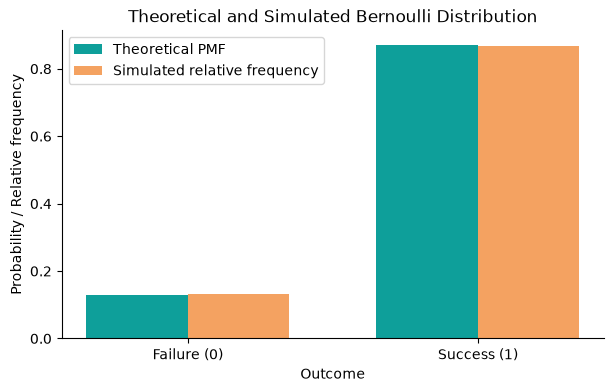

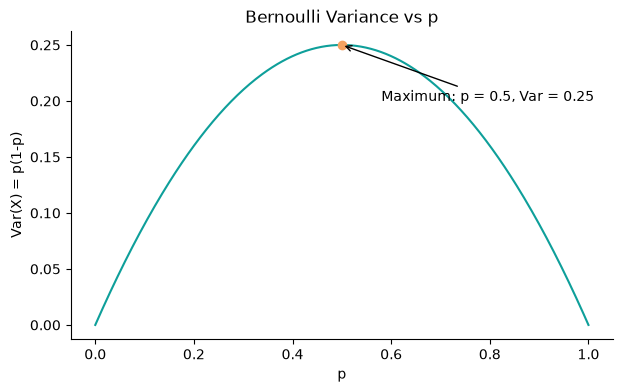

In [8]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------

n = 2000
successes = 1740
p = successes / n

simulated = stats.bernoulli.rvs(p, size=n, random_state=42)
simulated_proportion = np.mean(simulated)

print("Theoretical p:", round(p, 4))
print("Simulated proportion:", round(simulated_proportion, 4))

x = [0, 1]
theoretical_pmf = stats.bernoulli.pmf(x, p)
simulated_relative = [np.mean(simulated == 0), np.mean(simulated == 1)]

width = 0.35
plt.bar(np.array(x) - width/2, theoretical_pmf, width=width, color=DISCRETE_COLOR, label="Theoretical PMF")
plt.bar(np.array(x) + width/2, simulated_relative, width=width, color=HIGHLIGHT_COLOR, label="Simulated relative frequency")
plt.xticks(x, ["Failure (0)", "Success (1)"])
plt.xlabel("Outcome")
plt.ylabel("Probability / Relative frequency")
plt.title("Theoretical and Simulated Bernoulli Distribution")
plt.legend()
plt.show()

p_values = np.linspace(0, 1, 400)
variance = p_values * (1 - p_values)
max_p = 0.5
max_variance = max_p * (1 - max_p)

plt.plot(p_values, variance, color=DISCRETE_COLOR)
plt.plot(max_p, max_variance, marker="o", color=HIGHLIGHT_COLOR)
plt.annotate("Maximum: p = 0.5, Var = 0.25", (max_p, max_variance), xytext=(0.58, 0.20), arrowprops=dict(arrowstyle="->"))
plt.xlabel("p")
plt.ylabel("Var(X) = p(1-p)")
plt.title("Bernoulli Variance vs p")
plt.show()

# ------------------------------------------------------------

---
# Part B — Binomial distribution
*Recall:* $P(X=k) = \binom{n}{k}p^k(1-p)^{n-k}$, $\;E[X]=np$, $\;Var(X)=np(1-p)$.

## Q3. Guessing a multiple-choice quiz &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📝 An online quiz has **12 multiple-choice questions**, each with **4 options** and exactly one correct answer. A student who has not studied guesses every answer at random. Let $X$ = number of questions answered correctly.
>
> **(a)** State $n$ and $p$, check that the **BINS** conditions hold, and compute $P(X=5)$ **by hand**, showing the value of $\binom{12}{5}$.
> **(b)** Find the mean and the variance of $X$.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
>

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 




**(a)** $n=12$ and $p=1/4=0.25$. The BINS conditions hold: Binary outcomes (correct/incorrect), Independent guesses, fixed Number of 12 trials, and the Same probability $p=0.25$ on each trial.

$\binom{12}{5}=\frac{12!}{5!7!}=792$.

$P(X=5)=\binom{12}{5}(0.25)^5(0.75)^7=792(0.25)^5(0.75)^7\approx0.1032$.

**(b)** $E[X]=np=12(0.25)=3$.

$Var(X)=np(1-p)=12(0.25)(0.75)=2.25$.

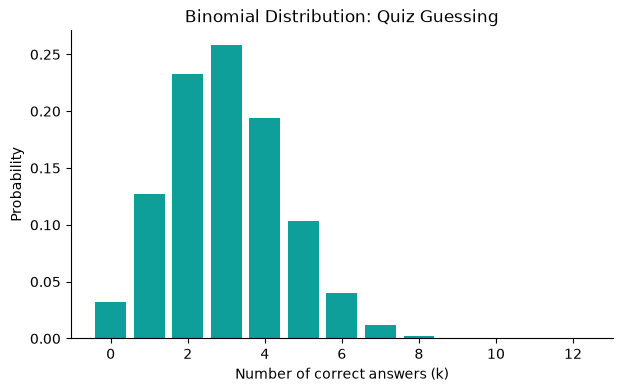

P(X=5): 0.1032
Mean: 3.0
Variance: 2.25


In [9]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
n = 12
p = 1/4
k = np.arange(0, n + 1)
pmf = stats.binom.pmf(k, n, p)

plt.bar(k, pmf, color=DISCRETE_COLOR)
plt.xlabel("Number of correct answers (k)")
plt.ylabel("Probability")
plt.title("Binomial Distribution: Quiz Guessing")
plt.show()

print("P(X=5):", round(stats.binom.pmf(5, n, p), 4))
print("Mean:", stats.binom.mean(n, p))
print("Variance:", stats.binom.var(n, p))


# ------------------------------------------------------------

#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> 
> 
> 
> 
> 


---
# Part C — Poisson distribution
*Recall:* $P(X=k) = \dfrac{\lambda^k e^{-\lambda}}{k!}$, $\;E[X]=Var(X)=\lambda$.

## Q5. Help-desk emails &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📧 The IT help-desk of a college receives on average **3 emails per hour**. Let $X$ = number of emails received in one hour.
>
> **(a)** Compute $P(X = 0)$ and $P(X = 2)$ **by hand**, showing the substitution into the formula ($e^{-3} \approx 0.0498$).
> **(b)** State the mean and the variance, and explain in one line what is special about them for a Poisson distribution.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
> - prints $P(X=0)$, $P(X=2)$ and $P(X \le 5)$,
> - prints the smallest value of $k$ for which $P(X \le k) \ge 0.95$ (use `.ppf` or a loop).

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


**(a)** For one hour, $\lambda=3$.

$P(X=0)=rac{3^0e^{-3}}{0!}=e^{-3}pprox0.0498$.

$P(X=2)=rac{3^2e^{-3}}{2!}=rac{9(0.0498)}{2}pprox0.2240$.

**(b)** $E[X]=\lambda=3$ and $Var(X)=\lambda=3$. For a Poisson distribution, the mean and variance are equal.

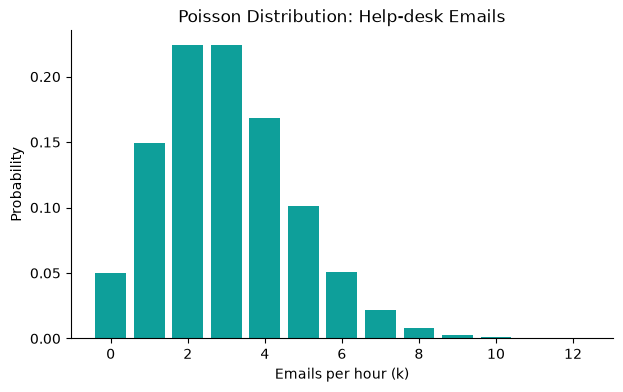

P(X=0): 0.0498
P(X=2): 0.224
P(X<=5): 0.9161
Smallest k with P(X<=k)>=0.95: 6


In [11]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------

la = 3
k = np.arange(0, 13)
pmf = stats.poisson.pmf(k, la)

plt.bar(k, pmf, color=DISCRETE_COLOR)
plt.xlabel("Emails per hour (k)")
plt.ylabel("Probability")
plt.title("Poisson Distribution: Help-desk Emails")
plt.show()

print("P(X=0):", round(stats.poisson.pmf(0, la), 4))
print("P(X=2):", round(stats.poisson.pmf(2, la), 4))
print("P(X<=5):", round(stats.poisson.cdf(5, la), 4))
print("Smallest k with P(X<=k)>=0.95:", int(stats.poisson.ppf(0.95, la)))

# ------------------------------------------------------------

## Q6. Server errors over a night shift &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 🖥️ A web server logs errors at an average rate of **1.5 errors per hour**. The night shift runs from 10 pm to 6 am, i.e. **8 hours**.
>
> **(a)** Find the value of $\lambda$ for the **whole 8-hour shift**, and compute by hand the probability of a **clean shift** (zero errors in the 8 hours).
> **(b)** State the mean and variance for the 8-hour window. The on-call engineer is paged if **more than 18 errors** occur in the shift — write the expression for that probability and name the `scipy` function that gives it directly.
> **(c)** Write Python code that:
> - creates **two subplots side by side** — the PMF for the 1-hour window ($\lambda = 1.5$) and the PMF for the 8-hour window — each with its own sensible range of $k$, title and labels,


#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> 
> 
> 
> 
> 


**(a)** The rate is 1.5 errors/hour and the shift is 8 hours, so

$\lambda=1.5	imes8=12$.

Clean shift:

$P(X=0)=rac{12^0e^{-12}}{0!}=e^{-12}pprox0.000006$.

**(b)** For the 8-hour window, $E[X]=Var(X)=\lambda=12$.

More than 18 errors:

$P(X>18)=1-P(X\le18)$.

In SciPy this is given directly by `stats.poisson.sf(18, 12)`.

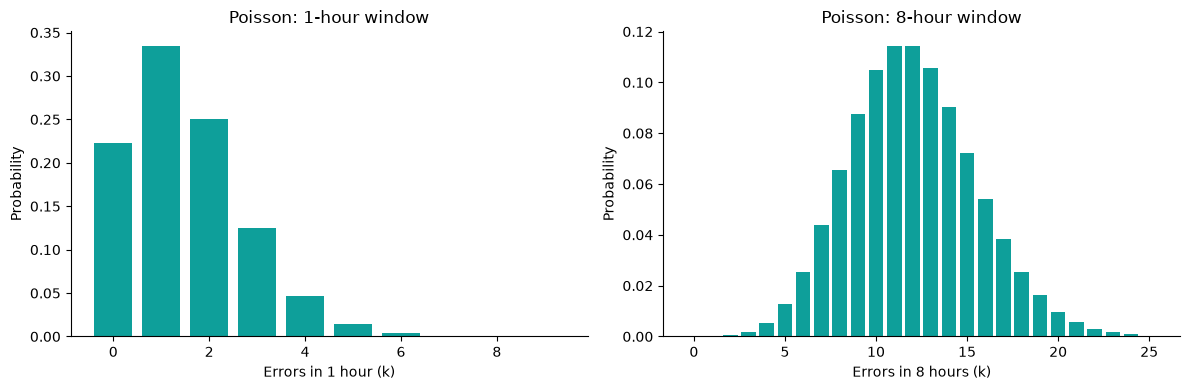

8-hour lambda: 12.0
P(X>18): 0.0374


In [12]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
la_1 = 1.5
la_8 = 1.5 * 8

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

k1 = np.arange(0, 10)
pmf1 = stats.poisson.pmf(k1, la_1)
axes[0].bar(k1, pmf1, color=DISCRETE_COLOR)
axes[0].set_xlabel("Errors in 1 hour (k)")
axes[0].set_ylabel("Probability")
axes[0].set_title("Poisson: 1-hour window")

k8 = np.arange(0, 26)
pmf8 = stats.poisson.pmf(k8, la_8)
axes[1].bar(k8, pmf8, color=DISCRETE_COLOR)
axes[1].set_xlabel("Errors in 8 hours (k)")
axes[1].set_ylabel("Probability")
axes[1].set_title("Poisson: 8-hour window")

plt.tight_layout()
plt.show()

print("8-hour lambda:", la_8)
print("P(X>18):", round(stats.poisson.sf(18, la_8), 4))
# ------------------------------------------------------------

---
# Part D — Normal distribution
*Recall:* $f(x)=\dfrac{1}{\sigma\sqrt{2\pi}}e^{-(x-\mu)^2/2\sigma^2}$, $\;Z=\dfrac{X-\mu}{\sigma}$, $\;E[X]=\mu$, $\;Var(X)=\sigma^2$.

## Q7. Battery life of a phone &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🔋 The battery life of a phone model is normally distributed with a mean of **18 hours** and a standard deviation of **1.5 hours**. Let $X$ = battery life of a randomly chosen phone.
>
> **(a)** Compute the **Z-score** for a battery life of 15 hours and say in words what that Z-score means.
> **(b)** Using the 68–95–99.7 rule, state the interval of battery lives that contains about **95%** of the phones. Show how you obtained it.
> **(c)** Write Python code that:
> - generates 400 equally spaced values of $x$ over $\mu \pm 4\sigma$ and computes the PDF,
> - plots the curve in `CONTINUOUS_COLOR` with a title and axis labels,
.

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 



**(a)**

$Z=rac{X-\mu}{\sigma}=rac{15-18}{1.5}=-2$.

So a 15-hour battery life is **2 standard deviations below the mean**.

**(b)** About 95% of observations lie within $\mu\pm2\sigma$.

$18\pm2(1.5)=18\pm3$, so the interval is **15 to 21 hours**.

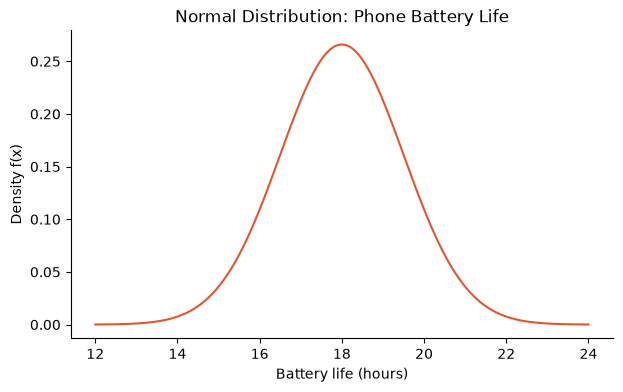

In [13]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------

mu = 18
sigma = 1.5

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf = stats.norm.pdf(x, mu, sigma)

plt.plot(x, pdf, color=CONTINUOUS_COLOR)
plt.xlabel("Battery life (hours)")
plt.ylabel("Density f(x)")
plt.title("Normal Distribution: Phone Battery Life")
plt.show()

# ------------------------------------------------------------

## Q8. Calibrating a coffee machine &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> ☕ A vending machine fills cups with coffee. The fill volume is normally distributed with a mean of **200 ml**, but the standard deviation is **not known**. The service log shows that **2.5% of cups overflow**, which happens whenever the fill exceeds **210 ml**.
>
> **(a)** Using the standard normal value $z_{0.975} \approx 1.96$, find the standard deviation $\sigma$ of the fill volume. Show the working.
> **(b)** With that $\sigma$, find the volume below which only **1%** of cups fall (the 1st percentile), and state which `scipy` function gives it. A customer complains if the cup holds less than **190 ml** — write the expression for that probability.
> **(c)** Write Python code that:
> - computes $\sigma$ using `stats.norm.ppf` rather than the rounded 1.96,
> - plots the PDF over a sensible range in `CONTINUOUS_COLOR`,



#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> 
> 
> 
> 
> 


**(a)** Since 2.5% overflow, $P(X>210)=0.025$, so $P(X\le210)=0.975$.

Using $z_{0.975}pprox1.96$:

$1.96=rac{210-200}{\sigma}$

$\sigma=rac{10}{1.96}pprox5.102	ext{ ml}$.

**(b)** The 1st percentile is given by `stats.norm.ppf(0.01, 200, sigma)`. Using the exact SciPy value for $z_{0.975}$ gives approximately **188.1307 ml**.

For a fill below 190 ml, the probability is $P(X<190)=	ext{stats.norm.cdf}(190,200,\sigma)$, approximately **0.0250**.

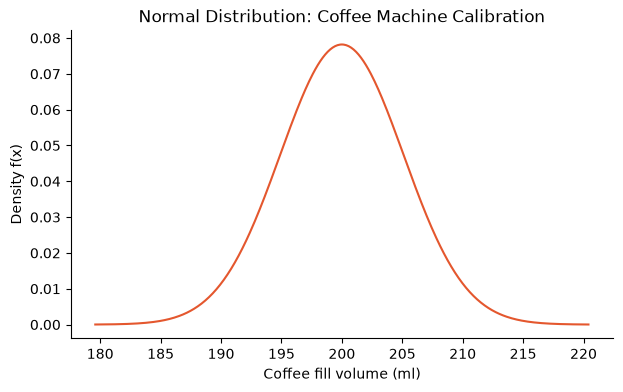

z_0.975: 1.96
sigma: 5.1021
1st percentile: 188.1307 ml
P(X<190): 0.025


In [14]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
mu = 200
z_975 = stats.norm.ppf(0.975)
sigma = (210 - mu) / z_975

p1 = stats.norm.ppf(0.01, mu, sigma)
p190 = stats.norm.cdf(190, mu, sigma)

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf = stats.norm.pdf(x, mu, sigma)

plt.plot(x, pdf, color=CONTINUOUS_COLOR)
plt.xlabel("Coffee fill volume (ml)")
plt.ylabel("Density f(x)")
plt.title("Normal Distribution: Coffee Machine Calibration")
plt.show()

print("z_0.975:", round(z_975, 4))
print("sigma:", round(sigma, 4))
print("1st percentile:", round(p1, 4), "ml")
print("P(X<190):", round(p190, 4))
# ------------------------------------------------------------

---
# Part E — Uniform distribution
*Recall:* $f(x)=\dfrac{1}{b-a}$ for $a \le x \le b$, $\;P(c \le X \le d)=\dfrac{d-c}{b-a}$, $\;E[X]=\dfrac{a+b}{2}$, $\;Var(X)=\dfrac{(b-a)^2}{12}$.

⚠️ **Note on `scipy`:** for a uniform distribution on $[a, b]$ you must use `loc=a` and `scale=b-a`, **not** `loc=a, scale=b`.

## Q9. Waiting for the campus shuttle &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🚌 The campus shuttle leaves the gate exactly every **15 minutes**. A student walks up to the stop at a completely random moment, so her waiting time $X$ is uniformly distributed between **0 and 15 minutes**.
>

> **(a)** Find the mean waiting time and the variance, showing the substitution.
> **(b)** Write Python code that:
> - plots the PDF as a flat line/rectangle over $[0, 15]$ in `CONTINUOUS_COLOR` (extend the x-axis a little beyond the range so the flat top is clear),


#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> 
> 
> 
> 
> 


**(a)**

$E[X]=rac{a+b}{2}=rac{0+15}{2}=7.5$ minutes.

$Var(X)=rac{(b-a)^2}{12}=rac{(15-0)^2}{12}=18.75$ minutes$^2$.

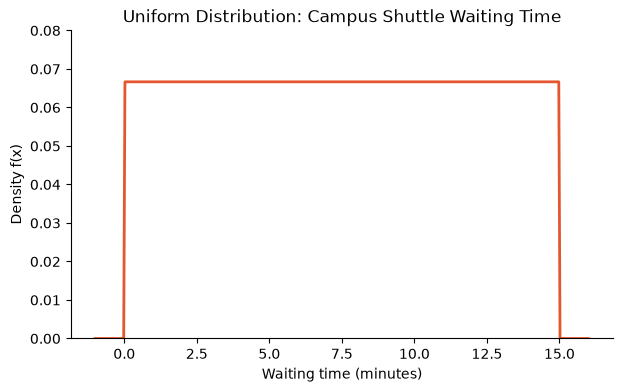

Mean: 7.5
Variance: 18.75


In [16]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
a = 0
b = 15

x = np.linspace(a - 1, b + 1, 400)
pdf = stats.uniform.pdf(x, loc=a, scale=b-a)

plt.plot(x, pdf, color=CONTINUOUS_COLOR, lw=2)
plt.xlabel("Waiting time (minutes)")
plt.ylabel("Density f(x)")
plt.title("Uniform Distribution: Campus Shuttle Waiting Time")
plt.ylim(0, 0.08)
plt.show()

print("Mean:", stats.uniform.mean(loc=a, scale=b-a))
print("Variance:", stats.uniform.var(loc=a, scale=b-a))
# ------------------------------------------------------------